**The Inference Engine**

C:\Users\rajam\miniconda3\envs\video_fusion\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 50 classes.
Loading Model...
Initializing Fusion Model Components...
Loading VideoMAE weights (this happens once)...


C:\Users\rajam\AppData\Local\Temp\ipykernel_26404\2777447766.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH))


Model Loaded Successfully!

Testing on video: data/UCF50\Basketball\v_Basketball_g01_c01.avi
✅ True Label: Basketball
🤖 Prediction: Basketball
📊 Confidence: 87.76%


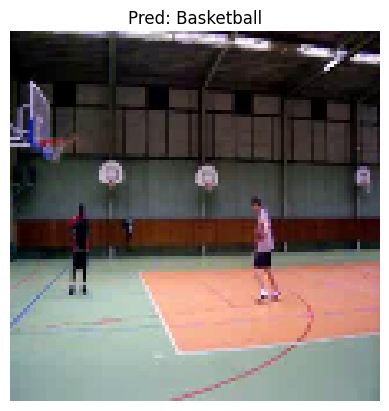

In [1]:
# FILE: 04_Inference_Core.ipynb

import torch
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from models.fusion_model import VideoFusionModel

# --- CONFIG ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "checkpoints/fusion_model_epoch_5.pth" # Load your best model
DATASET_ROOT = "data/UCF50" # We need class names from here

# 1. RE-CREATE CLASS MAPPING
# We need to know that Output 0 = "Baseball", Output 1 = "Basketball", etc.
# This must match exactly how we sorted folders during training.
classes = sorted(os.listdir(DATASET_ROOT))
classes = [c for c in classes if os.path.isdir(os.path.join(DATASET_ROOT, c))]
idx_to_class = {i: cls for i, cls in enumerate(classes)}

print(f"Loaded {len(classes)} classes.")

# 2. LOAD THE TRAINED MODEL
print("Loading Model...")
model = VideoFusionModel(num_classes=50, freeze_backbones=False).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH))
model.eval() # Set to evaluation mode (turns off Dropout)
print("Model Loaded Successfully!")

# 3. DEFINE INFERENCE PREPROCESSING (The "Chef" is back)
def process_video_for_inference(video_path):
    """
    Reads a raw video, resizes to 112x112, samples 16 frames.
    Returns: Tensor (1, 3, 16, 112, 112) -> Batch size of 1
    """
    cap = cv2.VideoCapture(video_path)
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        print("Error: Could not read video.")
        return None

    # Uniform sampling
    if total_frames < 16:
        indices = list(range(total_frames))
    else:
        indices = np.linspace(0, total_frames - 1, 16).astype(int)

    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret: break
        if i in indices:
            frame = cv2.resize(frame, (112, 112))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
            if len(frames) == 16: break
    cap.release()

    # Pad if short
    frames = np.array(frames)
    if len(frames) < 16:
        padding = np.zeros((16 - len(frames), 112, 112, 3), dtype=np.uint8)
        frames = np.concatenate((frames, padding), axis=0) if len(frames) > 0 else padding

    # Normalize & Permute
    frames = frames / 255.0
    tensor = torch.FloatTensor(frames).permute(3, 0, 1, 2) # (C, T, H, W)
    
    # Add Batch Dimension: (1, C, T, H, W)
    return tensor.unsqueeze(0)

# 4. RUN A TEST PREDICTION
# Pick a random video to test
test_class = "Basketball" # Change this to test different actions
test_folder = os.path.join(DATASET_ROOT, test_class)
test_video = os.path.join(test_folder, os.listdir(test_folder)[0])

print(f"\nTesting on video: {test_video}")

input_tensor = process_video_for_inference(test_video)

if input_tensor is not None:
    input_tensor = input_tensor.to(DEVICE)
    
    with torch.no_grad():
        outputs = model(input_tensor)
        # Get Probabilities using Softmax
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probs, 1)
        
    predicted_label = idx_to_class[predicted_idx.item()]
    confidence_score = confidence.item() * 100
    
    print(f"✅ True Label: {test_class}")
    print(f"🤖 Prediction: {predicted_label}")
    print(f"📊 Confidence: {confidence_score:.2f}%")
    
    # Show the video frame
    plt.imshow(cv2.cvtColor(cv2.imread(test_video.replace('.avi', '').replace('.mp4', '')), cv2.COLOR_BGR2RGB) if False else input_tensor[0, :, 0, :, :].cpu().permute(1, 2, 0))
    plt.title(f"Pred: {predicted_label}")
    plt.axis('off')
    plt.show()